<a href="https://colab.research.google.com/github/lilyfwu/MLAI-Economic-Mobility/blob/main/RF%20project_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview
### Data:
From Opportunity Insights.

I have a dataset (Table 4) with different outcomes regarding economic mobility for people born between 1978-1992 by commuting zone (CZ), race, gender, and parent income percentile. There are 740 CZs.
I have another dataset (Table 9) with 157 covariate columns, including share of single parent households, share of people with higher education, and foreign-born share, for each CZ, organized by decade: 1980, 1990, 2000, 2010.

Why economically interesting: much research has looked into what determines economic mobility (Chetty....). His randomized controlled trial work on relocations has been criticized; this project can help inform the ethical reading of such policies, give a picture of which place characteristics play the biggest role in mobility.

### Research Question:
For each birth cohort between 1980-1992, which CZ features, measured in 1980 as proxies for circumstances at birth, best predict their adult economic mobility? Are the top predictors stable across birth cohorts?

### Method:
Random forest (RF) for each birth cohort, 13 in total. RF is a specific type of decision-tree algorithm, where the algorithm splits the predictor space sequentially based on which split will minimize the total residual sum of squares within each of the resulting regions. Multiple trees are often formed from partitions of the training set (bootstrapping) and their predictions are averaged together (bagging); RF is bagging but with an additional constraint that the algorithm can only consider a randomly drawn subset of predictors at each split - without this, the same strong predictors are likely to be used in each tree's first splits, making the trees correlated and raising the variance of the averaged prediction.

I will compare each RF's permutation importance ranking across cohorts.

### Outcome (Y):
Average adult income rank of a child raised in each CZ by parents at the 25th percentile of the income distribution, pooled across race and gender.

### Predictors (X)
To ensure my question is well-defined and sufficiently narrow in scope (also discussed in the following section), I am left with eight 1980 CZ-level covariates, pooled by race (white and blank) except for the eighth:
1. employment rate,
2. share of adults with a college degree,
3. median household income,
4. per-capita income,
5. share below the poverty line,
6. share of single-parent households,
7. foreign-born share,
8. share who are white.

### Notes on data selection
These features are selected for prediction because they are 1) complete in the data and 2) measured at or before birth for every cohort. My objective is to get at a "circumstances at birth" effect, although this is necessarily a proxy because covariates are reported only by decade: the 1980 birth cohort receive the 1980 covariates at birth, while the 1989 cohort "receive" the 1980 covariates at age 9.

While the cohorts born 1990-1992 actually "receive" the 1990 covariates upon birth (this would more accurately examine a circumstances-at-birth effect for them), I think it would be too difficult to compare the 13 cohorts because 1) there are a few more covariates measured at 1990 that were not measured at 1980 and 2) I worry about collinearity between 1980 and 1990 versions of a feature, as ex. demographic levels/place characteristics persist over time. I worry that the random forest could  divide permutation importance between what is essentially the same feature, just recorded at different time points.

Predicting the 13 cohorts on 1980 covariates loses some nuance, but ultimately I think it's more interpretable, because the cohorts are compared on one shared feature set and any changes in mobility predictors can be attributed to birth year rather than something else.

The remaining dropped covariate columns:
#### Beyond the temporal scope
- 2000, 2009, and 2010 levels of covariates
- all changes in levels, computed as (2000 level - 1980 level), (2010 - 1990), (2009 - 1990)
#### Non-random missingness:
- share of black people, which could be because CZs with very few black people do not report(?); I keep share_white1980 because it gives a complementary snapshot
#### Not predictors:
- standard errors for each covariate



# 0. Setup

In [9]:
# importing relevant libraries using the W3 Colab tutorial as reference
import warnings
warnings.filterwarnings("ignore") # for readability

import gdown # my outcome dataset exceeds GitHub's 25MB limit,
# so I'm having it pull from my Google Drive

import numpy as np # random sim and fast array ops

import pandas as pd # dataframes

import matplotlib.pyplot as plt # visualizations

from matplotlib.lines import Line2D # 2D lines

from mpl_toolkits.mplot3d import Axes3D #3D plotting projection

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
# training, testing, and cross-validation/tuning

from sklearn.pipeline import make_pipeline
# efficiency, chains preprocessing steps into one estimator

from sklearn.linear_model import LinearRegression
# plan to use this as baseline for RF's performance to be judged against

from sklearn.tree import DecisionTreeRegressor, plot_tree
# in case I look at single tree model; plot_tree draws the fitted tree
# as a sequence of split rules

from sklearn.ensemble import RandomForestRegressor
# anticipate using RF, not Extra Trees or Boosting

from sklearn.metrics import mean_squared_error, r2_score # judging model performance

from sklearn.inspection import permutation_importance
# to display the most important features for prediction

from IPython.display import HTML # was used to put
# cohort permutation ranking tables in a grid because just displaying them
# took up a lot of vertical space

# 1.1 Loading data

In [10]:
"""I created a GitHub account so the code can automatically run and pull the
csv files from there; the outcomes dataset (Table 4) ended up being too big without
a big workaround in GitHub. I'm new to it and didn't feel like fighting with it so
I'm having that pulled from my Google Drive instead.
"""
gdown.download("https://drive.google.com/file/d/1X-eRORpru0pWoW-ZuhV32ogVA30PP5pe/view?usp=drive_link", "Table_4_cz_by_cohort_estimates.csv", quiet=False, fuzzy=True)
outcomes_cz = pd.read_csv("Table_4_cz_by_cohort_estimates.csv")

covariates_cz = pd.read_csv("https://raw.githubusercontent.com/lilyfwu/MLAI-Economic-Mobility/refs/heads/main/Table_9_cz_covariates.csv")


Downloading...
From: https://drive.google.com/uc?id=1X-eRORpru0pWoW-ZuhV32ogVA30PP5pe
To: /content/Table_4_cz_by_cohort_estimates.csv
100%|██████████| 52.7M/52.7M [00:00<00:00, 178MB/s]


In [11]:
outcomes_cz = pd.read_csv('Table_4_cz_by_cohort_estimates.csv')
print("\nEconomic Mobility Outcomes from Table 4 CSV:")
display(outcomes_cz.head(16))
# the first 15 rows show the full 15 birth cohorts: 1978-1992 in the CZ Johnson City.
# the next 15 rows would show the same birth cohorts in Morristown, and so on

covariates_cz = pd.read_csv("https://raw.githubusercontent.com/lilyfwu/MLAI-Economic-Mobility/refs/heads/main/Table_9_cz_covariates.csv")
print("\nCovariates from Table 9 CSV:")
display(covariates_cz.head())

print("\nShape of the datasets:")
display(covariates_cz.shape)
display(outcomes_cz.shape)


Economic Mobility Outcomes from Table 4 CSV:


,cz,cohort,cz_name,kfr_aian_female_p1,kfr_asian_female_p1,kfr_black_female_p1,kfr_hisp_female_p1,kfr_pooled_female_p1,kfr_white_female_p1,kfr_aian_male_p1,...,kfi_asian_pooled_p100,kii_asian_pooled_p100,kfi_black_pooled_p100,kii_black_pooled_p100,kfi_hisp_pooled_p100,kii_hisp_pooled_p100,kfi_pooled_pooled_p100,kii_pooled_pooled_p100,kfi_white_pooled_p100,kii_white_pooled_p100
0,100,1978,Johnson City,NaN,NaN,0.240735,NaN,0.327321,0.328567,NaN,...,NaN,NaN,32608.648,29550.422,40010.664,29694.957,48076.992,36270.195,48313.188,36373.016
1,100,1979,Johnson City,NaN,NaN,0.348327,NaN,0.357462,0.357646,NaN,...,NaN,NaN,35564.012,26531.928,52867.332,45336.152,48509.246,37402.059,48588.176,37429.598
2,100,1980,Johnson City,NaN,NaN,0.234071,NaN,0.364645,0.366858,NaN,...,NaN,NaN,39166.137,43188.402,NaN,NaN,47656.352,37978.910,47783.398,37909.855
3,100,1981,Johnson City,NaN,NaN,0.276927,NaN,0.333514,0.334792,NaN,...,NaN,NaN,39821.094,37773.422,22970.234,14384.382,48069.145,37127.504,48387.004,37256.953
4,100,1982,Johnson City,NaN,NaN,0.366546,NaN,0.308767,0.307034,NaN,...,40445.074,32602.896,37004.367,31514.977,44583.633,40271.926,46800.020,36608.613,46989.813,36674.766
5,100,1983,Johnson City,NaN,NaN,0.292990,NaN,0.321931,0.322365,NaN,...,NaN,NaN,32300.154,29765.057,53904.566,33925.637,47773.926,37273.051,47900.746,37364.797
6,100,1984,Johnson City,NaN,NaN,0.233848,NaN,0.344923,0.345876,NaN,...,NaN,NaN,31610.479,22931.004,46395.547,37218.262,47497.031,37193.676,47827.563,37455.930
7,100,1985,Johnson City,NaN,NaN,0.224859,NaN,0.317676,0.319256,NaN,...,NaN,NaN,42308.500,35950.273,30500.891,10997.538,50201.492,38374.703,50382.711,38544.332
8,100,1986,Johnson City,NaN,NaN,0.214640,NaN,0.303886,0.305392,NaN,...,NaN,NaN,39918.469,32029.408,42018.098,31966.113,50251.633,39156.145,50432.668,39281.895
9,100,1987,Johnson City,NaN,NaN,0.227267,NaN,0.296270,0.297383,NaN,...,25532.146,19620.828,34266.000,31636.330,52766.840,39612.117,52806.188,40110.234,53341.234,40339.359



Covariates from Table 9 CSV:


,cz,czname,emp_pooled2010,emp_white2010,emp_black2010,emp_pooled1980,emp_white1980,emp_black1980,emp_pooled1990,emp_white1990,...,change_singlepar_black1980_2000,change_singlepar_black1990_2010,change_singlepar_pooled1980_2000,change_singlepar_pooled1990_2010,change_foreign_share1980_2000,change_foreign_share1990_2009,change_gini1990_2010,pop_pooled2010,pop_pooled1990,state
0,100,Johnson City,0.636499,0.639144,0.603400,0.610026,0.611880,0.538735,0.662941,0.665009,...,0.097918,0.097549,0.115787,0.125714,0.981399,-0.675266,0.023850,609299,524270,47
1,200,Morristown,0.659809,0.662172,0.607347,0.602076,0.603329,0.557871,0.675404,0.678159,...,0.175894,0.063989,0.115388,0.122484,0.970982,-0.734596,0.023867,262159,180775,47
2,301,Middlesborough,0.515640,0.517874,0.267745,0.479291,0.481603,0.365777,0.520650,0.524621,...,0.187402,-0.076293,0.120876,0.122243,0.987978,-0.675431,-0.007626,67723,64382,21
3,302,Knoxville,0.674654,0.683174,0.576002,0.624249,0.629257,0.548750,0.682394,0.689464,...,0.148183,0.075750,0.090104,0.084475,0.968759,-0.686176,0.008278,814914,634523,47
4,401,Winston-Salem,0.683683,0.704346,0.617549,0.692744,0.706720,0.628145,0.743964,0.758017,...,0.128443,0.107358,0.093834,0.106305,0.933338,-0.655158,0.017461,551390,423152,37



Shape of the datasets:


(739, 159)

(11100, 723)

# 1.2 Merging and cleaning the raw datasets

In [12]:
# merge the parts that I'm interested in of these two raw datasets
outcome = "kir_pooled_pooled_p25"   # adult income rank, parents at the 25th percentile

features = [
    "emp_pooled1980",           # employment rate
    "frac_coll_pooled1980",     # college share
    "hhinc_median_pooled1980",  # median household income
    "percap_inc_pooled1980",    # per-capita income
    "poor_share_pooled1980",    # poverty share
    "singlepar_pooled1980",     # single-parent share
    "foreign_share1980",        # foreign-born share
    "share_white1980",          # racial composition (white share)
]

# trim Table 4: identifiers + outcome, restricted to birth cohorts 1980-1992
outcomes_trim = outcomes_cz[(outcomes_cz["cohort"] >= 1980) & (outcomes_cz["cohort"] <= 1992)]
outcomes_trim = outcomes_trim[["cz", "cz_name", "cohort", outcome]]

# trim Table 9: CZ id + the 8 fixed features
covariates_trim = covariates_cz[["cz"] + features]

# merge: attach each CZ's 1980 features to every cohort row for that CZ
merged_cz = outcomes_trim.merge(covariates_trim, on="cz", how="inner")

# no imputation since few missing values: drop any row missing the outcome or a feature
merged_cz = merged_cz.dropna(subset=[outcome] + features)

# save and inspect
merged_cz.to_csv("merged_cz.csv", index=False)
print("\nMerged economic mobility dataset (outcome + 8 covariates, cohorts 1980-1992):")
print("shape:", merged_cz.shape, "| unique CZs:", merged_cz["cz"].nunique())
display(merged_cz.head(13)) # features and outcome for the first CZ

# check that dropna removed all missing values
print(f"\nMissing Values per Column")
print(merged_cz.isna().sum())
# it's 0 in every column so we're good

# for descriptive stats, I want to get a picture of the unique CZs' features -
# in the full merged dataset, each CZ appears about 13x, I want each to count once
cz_level = merged_cz.drop_duplicates("cz")
print("\nFeature distribution across", len(cz_level), "unique CZs:")
display(cz_level[features].describe())

# Does the outcome vary by cohort?
display(merged_cz.groupby("cohort")[outcome].agg(["mean", "std"]))
# seems so. Overall mean economic mobility is between .437 and .454, so these people
# are in a higher income percentile than their parents (25th percentile) but still
# less wealthy than the median household.
# there also seems to be a downward trend in mobility from those born 1980 to
# those born 1992, but idk whether this is really a significant fluctuation.


Merged economic mobility dataset (outcome + 8 covariates, cohorts 1980-1992):
shape: (9436, 12) | unique CZs: 737


,cz,cz_name,cohort,kir_pooled_pooled_p25,emp_pooled1980,frac_coll_pooled1980,hhinc_median_pooled1980,percap_inc_pooled1980,poor_share_pooled1980,singlepar_pooled1980,foreign_share1980,share_white1980
0,100,Johnson City,1980,0.399946,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
1,100,Johnson City,1981,0.390845,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
2,100,Johnson City,1982,0.387940,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
3,100,Johnson City,1983,0.399292,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
4,100,Johnson City,1984,0.395632,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
5,100,Johnson City,1985,0.393094,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
6,100,Johnson City,1986,0.382586,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
7,100,Johnson City,1987,0.385533,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
8,100,Johnson City,1988,0.387023,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903
9,100,Johnson City,1989,0.390022,0.610026,0.109197,50135.28069,21565.895,0.15485,0.134148,0.006452,0.974903



Missing Values per Column
cz                         0
cz_name                    0
cohort                     0
kir_pooled_pooled_p25      0
emp_pooled1980             0
frac_coll_pooled1980       0
hhinc_median_pooled1980    0
percap_inc_pooled1980      0
poor_share_pooled1980      0
singlepar_pooled1980       0
foreign_share1980          0
share_white1980            0
dtype: int64

Feature distribution across 737 unique CZs:


,emp_pooled1980,frac_coll_pooled1980,hhinc_median_pooled1980,percap_inc_pooled1980,poor_share_pooled1980,singlepar_pooled1980,foreign_share1980,share_white1980
count,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000,737.000000
mean,0.639738,0.128864,53896.917321,23113.807597,0.153155,0.153100,0.025137,0.877605
std,0.059272,0.045797,11520.508162,4338.293713,0.062380,0.042568,0.031217,0.143156
min,0.417591,0.049313,29130.089490,11462.128000,0.041389,0.050218,0.001566,0.141379
25%,0.605871,0.096569,45541.832210,20253.766000,0.108774,0.124359,0.009521,0.817368
50%,0.645510,0.120187,53100.509380,22998.135000,0.139743,0.149312,0.016085,0.935023
75%,0.681005,0.150446,60127.930520,25351.043000,0.180768,0.181398,0.028675,0.978738
max,0.787795,0.392353,124630.306200,55269.641000,0.427453,0.332276,0.370629,0.998435


,mean,std
cohort,,
1980,0.452556,0.044728
1981,0.449504,0.046961
1982,0.450217,0.049615
1983,0.452379,0.047728
1984,0.454564,0.051288
1985,0.451329,0.051502
1986,0.450089,0.049913
1987,0.450503,0.051659
1988,0.442566,0.047426


# 2. Visualizing feature-outcome relationships
In the W3 tutorial colab, there's a note that we can't tell which features aremost important for prediction. (It picks experience and education as predictors of wage based on theory.)
Here, I didn't want to make an assumption about which features would be best to model against the outcome, so I asked Claude AI and it suggested to look at the Pearson and Spearman correlations - Spearman being a good juxtaposition because it doesn't make a parametric assumption about the x-y relationship, unlike Pearson (linear).

,pearson,spearman,abs_spearman
feature,,,
singlepar_pooled1980,-0.597,-0.591,0.591
emp_pooled1980,0.459,0.496,0.496
share_white1980,0.417,0.459,0.459
poor_share_pooled1980,-0.258,-0.335,0.335
percap_inc_pooled1980,0.193,0.280,0.280
foreign_share1980,0.122,0.264,0.264
hhinc_median_pooled1980,0.114,0.190,0.190
frac_coll_pooled1980,0.085,0.146,0.146


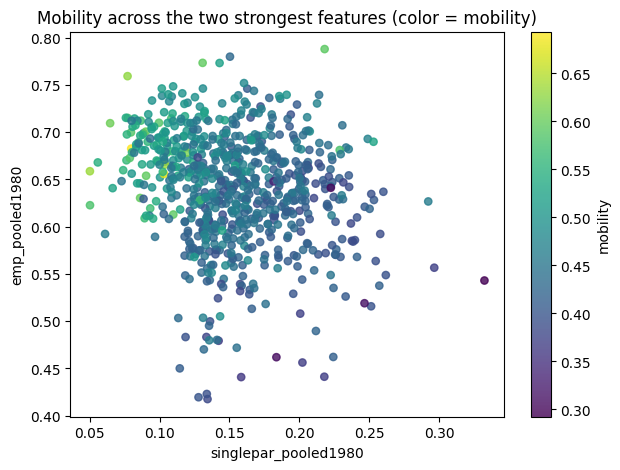

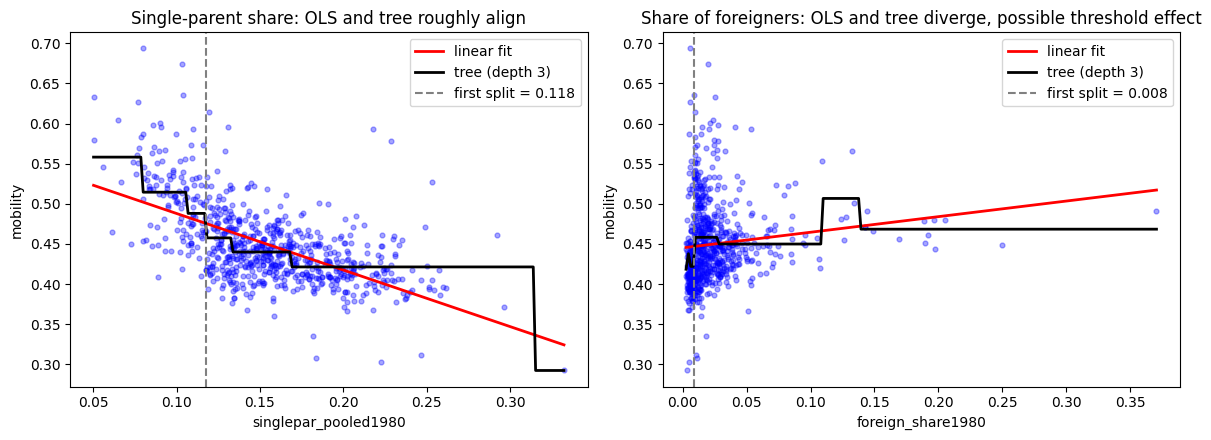

In [13]:
# getting a visual of which features correlate most with the outcome
# picked birth cohort 1986, no other reason than it's close to the middle so
# seems more representative, no "edge of the decade" effect (if they exist?)
cohort_1986 = merged_cz[merged_cz["cohort"] == 1986]

# building the rows; pearson is default, spearman gives monotonic association
rows = []
for feature in features:
    pearson  = cohort_1986[feature].corr(cohort_1986[outcome]) # linear association
    spearman = cohort_1986[feature].corr(cohort_1986[outcome], method="spearman")
    rows.append({"feature": feature, "pearson": pearson, "spearman": spearman})
corr = pd.DataFrame(rows).set_index("feature")

# Rank by strength of correlation (magnitude), regardless of sign:
# add an absolute-value column, sort on it, then show the table.
corr["abs_spearman"] = corr["spearman"].abs()
corr = corr.sort_values("abs_spearman", ascending=False)
display(corr.round(3))
"""for most of the features, pearson and spearman correlations don't differ much,
implying that there are linearities - HOWEVER, pooled per capita income,
foreign share, and fraction with bachelor's+ have a higher Spearman, implying
nonlinearities. But it's cool to see that the covariates that matter most
seem to be linear-adjacent, at least in an INDIVIDUAL correlation (not
considering non-additive effects, taking other covariates into account).
This correlation ranking, I think, also helps motivate using RF."""

# now with this taste for the features, plotting the two top features
# against outcome, expressed as color to maintain 2D. This is inspired from the
# W3 tutorial.
print(f"\n\n")
feat_x = "singlepar_pooled1980"
feat_y = "emp_pooled1980"

cohort_1986 = merged_cz[merged_cz["cohort"] == 1986]

fig, ax = plt.subplots(figsize=(7, 5))
scatterplot_1 = ax.scatter(
    cohort_1986[feat_x],
    cohort_1986[feat_y],
    c=cohort_1986[outcome],
    cmap="viridis",
    s=28,
    alpha=0.80,
)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title("Mobility across the two strongest features (color = mobility)")
plt.colorbar(scatterplot_1, ax=ax, label="mobility")
plt.show()

# this matches the intuition from seeing the correlations; the relationship
# seems pretty linear - higher mobility upper left, lower mobility lower right.

"""to get a further idea, plot OLS and a decision tree (depth 3
chosen arbitrarily, not optimized) on Single Parent Share and Foreign Share.
For reasons outlined above, expect to see that for Single Parent Share,
OLS and decision tree don't differ much. Whereas the flexible decision tree may
deviate from OLS for Foreign Share """

def plot_feature_vs_outcome(ax, df, feat, target, tree_depth=3):

    X = df[[feat]]
    y = df[target]

    # Each point is one commuting zone in this cohort.
    ax.scatter(X[feat], y, s=12, alpha=0.35, color="blue")

    # A dense grid of feature values so each fitted model draws a smooth curve.
    grid = pd.DataFrame({feat: np.linspace(X[feat].min(), X[feat].max(), 200)})

    # Red: the straight linear relationship
    linear = LinearRegression().fit(X, y)
    ax.plot(grid[feat], linear.predict(grid), color="red", lw=2, label="linear fit")

    # Black: a shallow tree that can bend with the data.
    tree = DecisionTreeRegressor(max_depth=tree_depth, random_state=42).fit(X, y)
    ax.plot(grid[feat], tree.predict(grid), color="black", lw=2,
            label=f"tree (depth {tree_depth})")

    # marking the first decisive split
    root_split = tree.tree_.threshold[0]
    ax.axvline(root_split, color="gray", ls="--", lw=1.5,
               label=f"first split = {root_split:.3f}")

    ax.set_xlabel(feat)
    ax.set_ylabel("mobility")
    ax.legend(loc="best")

# One representative cohort so each CZ appears once.
cohort_1986 = merged_cz[merged_cz["cohort"] == 1986]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_feature_vs_outcome(axes[0], cohort_1986, "singlepar_pooled1980", outcome)
plot_feature_vs_outcome(axes[1], cohort_1986, "foreign_share1980", outcome)
axes[0].set_title("Single-parent share: OLS and tree roughly align")
axes[1].set_title("Share of foreigners: OLS and tree diverge, possible threshold effect")
# possible threshold: those below foreign share of .008 have lower mobility outcomes,
# those above have higher mobility outcomes. But the difference is quite small
plt.tight_layout()
print(f"\n\n")
plt.show()

# Robustness check: Foreign Share is clustered below 0.05, so I wondered if that skewedness made
# the curvature look weird. I asked Claude to compute the Pearson correlation with
# the outcome for Foreign Share and on log(Foreign Share): 0.122 and 0.125 respectively,
# basically the same, so the curvature seems legitimate.

# 3.1 OLS performance as baseline

baseline (predict the mean):  test MSE = 0.00226

linear regression:  train MSE = 0.00115
linear regression: test MSE = 0.00098
linear regression: test R^2 = 0.567





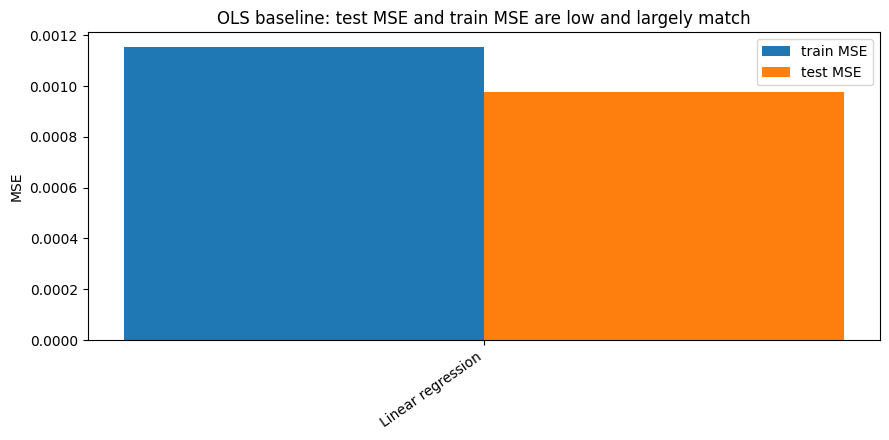

In [14]:
# OLS as baseline; RF should beat its test accuracy, but I don't think it'll do
# so by much given the linearity we've seen in the features most correlated
# with the outcome.
def evaluate_regression_model(model, X_train, y_train, X_test, y_test, name="model"):
  """Fit a regressor on the training data and report train and test MSE.
  Watch out for if train MSE is a lot smaller than test MSE, would signal overfitting.
  But tbh with only 8 features idk if there is much to memorize anyway?
  Also report R^2 to see what fraction of the variation in mobility is explained,
  but should be cautious about interpreting it because most of these features are collinear.
  I think it would also be good to have another metric besides MSE, since
  the economic mobility outcomes are fractions between 0 and 1 and tend to be <0.5,
  so the square deviations of (outcome-prediction) would get very small and hard
  to interpret in  one MSE.
  """
  model.fit(X_train, y_train)
  train_mse = mean_squared_error(y_train, model.predict(X_train))
  test_mse = mean_squared_error(y_test,  model.predict(X_test))
  test_r2 = r2_score(y_test, model.predict(X_test))
  print(f"{name}:  train MSE = {train_mse:.5f}")
  print(f"{name}: test MSE = {test_mse:.5f}")
  print(f"{name}: test R^2 = {test_r2:.3f}")
  return train_mse, test_mse

# Fit the baseline on the 1986 cohort. Each CZ appears once here, so a
# row split puts distinct CZs in train vs test (if the same CZ could show up
# in the training set and test set, there would be a leakage concern).
cohort_1986 = merged_cz[merged_cz["cohort"] == 1986]
X = cohort_1986[features]
y = cohort_1986[outcome]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# This should be the naive reference point: predict the training average for every CZ
baseline_mse = mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))
print(f"baseline (predict the mean):  test MSE = {baseline_mse:.5f}\n")

linear = LinearRegression()
linear = LinearRegression()
linear_train_mse, linear_test_mse = evaluate_regression_model(
    linear, X_train, y_train, X_test, y_test, name="linear regression")

"""like expected, the test MSE is super small - linear regression does well in
prediction accuracy and these 8 features can explain about 56.7% of the variation
in economic mobility. That's a really good result but be cautious because
the 8 features themselves probably reflect the same underlying properties of a
CZ, so the R^2 is probably overstated.
Train MSE is a bit bigger, but they are about equal."""

# plotting test MSE next to train MSE for visual
initial_table = pd.DataFrame({
 "model": ["Linear regression"],
 "train_mse": [linear_train_mse],
 "test_mse": [linear_test_mse],
})
plot_table = initial_table.sort_values("test_mse", ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(plot_table))
width = 0.38
ax.bar(positions - width / 2, plot_table["train_mse"], width, label="train MSE")
ax.bar(positions + width / 2, plot_table["test_mse"], width, label="test MSE")
ax.set_xticks(positions)
ax.set_xticklabels(plot_table["model"], rotation=35, ha="right")
ax.set_ylabel("MSE")
ax.set_title("OLS baseline: test MSE and train MSE are low and largely match")
ax.legend(loc='best')
plt.tight_layout()
print(f"\n\n")
plt.show()

# 3.2 Random Forest on 1986 Cohort

In [15]:
# tuning the RF with 5-fold cross validation on the training data -
# the training data is split into 5 folds and each fold has its turn
# being held-out while the other 4 folds in that round are used for training,
# then validated on that round's hold out.

def evaluate_regression_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    return {
        "model":        name,
        "train_mse":    mean_squared_error(ytr, model.predict(Xtr)),
        "test_mse":     mean_squared_error(yte, model.predict(Xte)),
        "test_r2":      r2_score(yte, model.predict(Xte)),
        "fitted_model": model,
    }

cv = KFold(n_splits=5, shuffle=True, random_state=42)

"""for hyperparameter grid: I again followed the tutorial's precedent for
hyperparameter choices, but asked Claude to  inspect if different parameter choices
would be relevant to my data. This led to adding 0.25 to max_features;
0.5 originally was the optimum so expanding the range is meant to see if an
even smaller hyperparameter value would be better."""
param_grid = {
    "max_leaf_nodes":   [8, 16, 32, None],
    "max_features":     [0.25, 0.5, 0.8, 1.0],
    "min_samples_leaf": [1, 5, 15],
}


"""the tutorial flagged that sklearn maximizes the score it is given, can't
directly minimize # MSE. So I follow the convention from tutorial,
"neg_mean_squared_error" - store MSE as a
# negative number, so a larger number is better because it's less negative
When we print it for viewing, we flip the sign back for interpretability."""
rf_search = GridSearchCV(
    RandomForestRegressor(n_estimators=300, random_state=42),
    param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,  # I learned this means to use all CPU cores for quick processing
    return_train_score=True, # keep training scores, to inspect overfitting
)

rf_search.fit(X_train, y_train)

print("best hyperparameters:", rf_search.best_params_)
print(f"best cross-validated MSE: {-rf_search.best_score_:.5f}")

"""one note before the full OLS vs RF comparison, it's interesting that the
optimal min samples per leaf is 1, since there could be just one CZ per leaf (overfit).
This motivates the random forest technique, decorrelating the trees so
the variance of the average decreases even further.
The intuition behind bagging in the first place was that the sample variance =
pop variance/n and since n>0, sample var < pop var.
"""

# the final RF results.
print(f"\n")
rf = rf_search.best_estimator_ # fit by the grid search
rf_train_mse = mean_squared_error(y_train, rf.predict(X_train))
rf_test_mse = mean_squared_error(y_test,  rf.predict(X_test))
rf_test_r2 = r2_score(y_test,  rf.predict(X_test))

print(f"random forest:  train MSE = {rf_train_mse:.5f}")
print(f"random forest: test MSE = {rf_test_mse:.5f}")
print(f"random forest: test R^2 = {rf_test_r2:.3f}")

# that the r^2 only increases to 65% confirms that the relationship is
# near-linear and additive in the first place.

best hyperparameters: {'max_features': 0.25, 'max_leaf_nodes': None, 'min_samples_leaf': 1}
best cross-validated MSE: 0.00105


random forest:  train MSE = 0.00014
random forest: test MSE = 0.00079
random forest: test R^2 = 0.650


In [16]:
# just looking
X_train.head()

,emp_pooled1980,frac_coll_pooled1980,hhinc_median_pooled1980,percap_inc_pooled1980,poor_share_pooled1980,singlepar_pooled1980,foreign_share1980,share_white1980
4257,0.633240,0.127071,59528.28909,25635.105,0.113278,0.155347,0.014780,0.966629
5882,0.700703,0.095835,48099.61854,22898.572,0.144026,0.103676,0.008985,0.991218
1358,0.635533,0.167740,60969.47255,28042.676,0.102456,0.194938,0.053906,0.888914
1488,0.651594,0.138938,57388.71549,22117.938,0.164014,0.200925,0.024649,0.678785
8612,0.672505,0.161487,57479.84931,25075.508,0.107415,0.147037,0.020353,0.957698


# 3.3 OLS vs RF (still on one cohort)

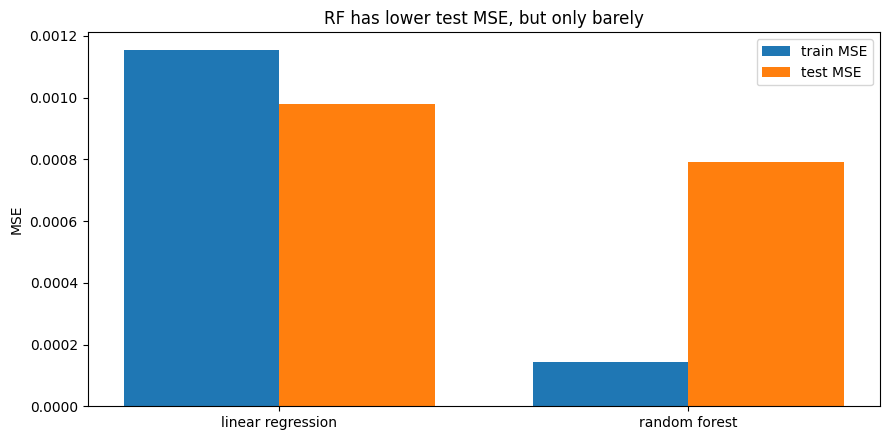

"The low train MSE is expected: with min_samples_leaf=1 the individual trees\ngrew fully and memorized the training rows.\nA good sign is that the ensemble generalized, shown by the held-out test set.\nAveraging canceled the trees' disagreement on unseen data points, reducing variance.\nRF test MSE (0.00079) < OLS test MSE (0.00098). Visible but not huge.\n\nThe train MSE << test MSE is also what more flexible methods in the tutorial,\nlike boosting and extra trees, produced. This is helping me understand\nthe bias-variance tradeoff: RF offers low bias because it's flexible to bend with\nthe data's patterns, but at the cost of high variance for each tree.\nDecorrelating and then averaging the trees lowers some of the variance."

In [17]:
# Want a side-by-side comparison of train MSE vs test MSE for both models.
# One note, refit a "fresh" linear model so the plot doesn't depend on variable
# names from earlier cells.
ols = LinearRegression().fit(X_train, y_train)

models       = ["linear regression", "random forest"]
train_scores = [mean_squared_error(y_train, ols.predict(X_train)), rf_train_mse]
test_scores  = [mean_squared_error(y_test,  ols.predict(X_test)),  rf_test_mse]

positions = np.arange(len(models))   # one slot per model
width = 0.38                         # two bars sit side by side within each slot

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(positions - width/2, train_scores, width, label="train MSE")
ax.bar(positions + width/2, test_scores,  width, label="test MSE")

ax.set_xticks(positions)
ax.set_xticklabels(models)
ax.set_ylabel("MSE")
ax.set_title("RF has lower test MSE, but only barely")
ax.legend()
plt.tight_layout()
plt.show()

"""The low train MSE is expected: with min_samples_leaf=1 the individual trees
grew fully and memorized the training rows.
A good sign is that the ensemble generalized, shown by the held-out test set.
Averaging canceled the trees' disagreement on unseen data points, reducing variance.
RF test MSE (0.00079) < OLS test MSE (0.00098). Visible but not huge.

The train MSE << test MSE is also what more flexible methods in the tutorial,
like boosting and extra trees, produced. This is helping me understand
the bias-variance tradeoff: RF offers low bias because it's flexible to bend with
the data's patterns, but at the cost of high variance for each tree.
Decorrelating and then averaging the trees lowers some of the variance."""

# 4. Fitting one RF on each of the remaining 12 cohorts.

Not re-tuning by cohort, but using the tuned hyperparameters for the 1986 cohort. Two reasons, 1) intuitively, the cohorts are structurally similar being born in the same decade and 2) by holding constant the hyperparameters for the model, differences across cohorts can be taken as coming from the data and not different settings.

    cohort    n  rf_train_mse  rf_test_mse  ols_test_mse  test_r2  dumb_mse
0     1980  720       0.00012      0.00080       0.00096  0.59181   0.00200
1     1981  722       0.00011      0.00119       0.00133  0.53538   0.00256
2     1982  722       0.00014      0.00091       0.00120  0.65150   0.00260
3     1983  725       0.00012      0.00090       0.00115  0.54227   0.00198
4     1984  724       0.00014      0.00105       0.00123  0.59162   0.00258
5     1985  724       0.00015      0.00117       0.00125  0.52739   0.00249
6     1986  726       0.00014      0.00079       0.00098  0.64991   0.00226
7     1987  728       0.00015      0.00141       0.00161  0.52076   0.00295
8     1988  727       0.00012      0.00070       0.00093  0.65238   0.00202
9     1989  728       0.00011      0.00103       0.00118  0.54781   0.00230
10    1990  728       0.00011      0.00097       0.00126  0.53985   0.00210
11    1991  726       0.00012      0.00085       0.00112  0.56540   0.00194
12    1992  

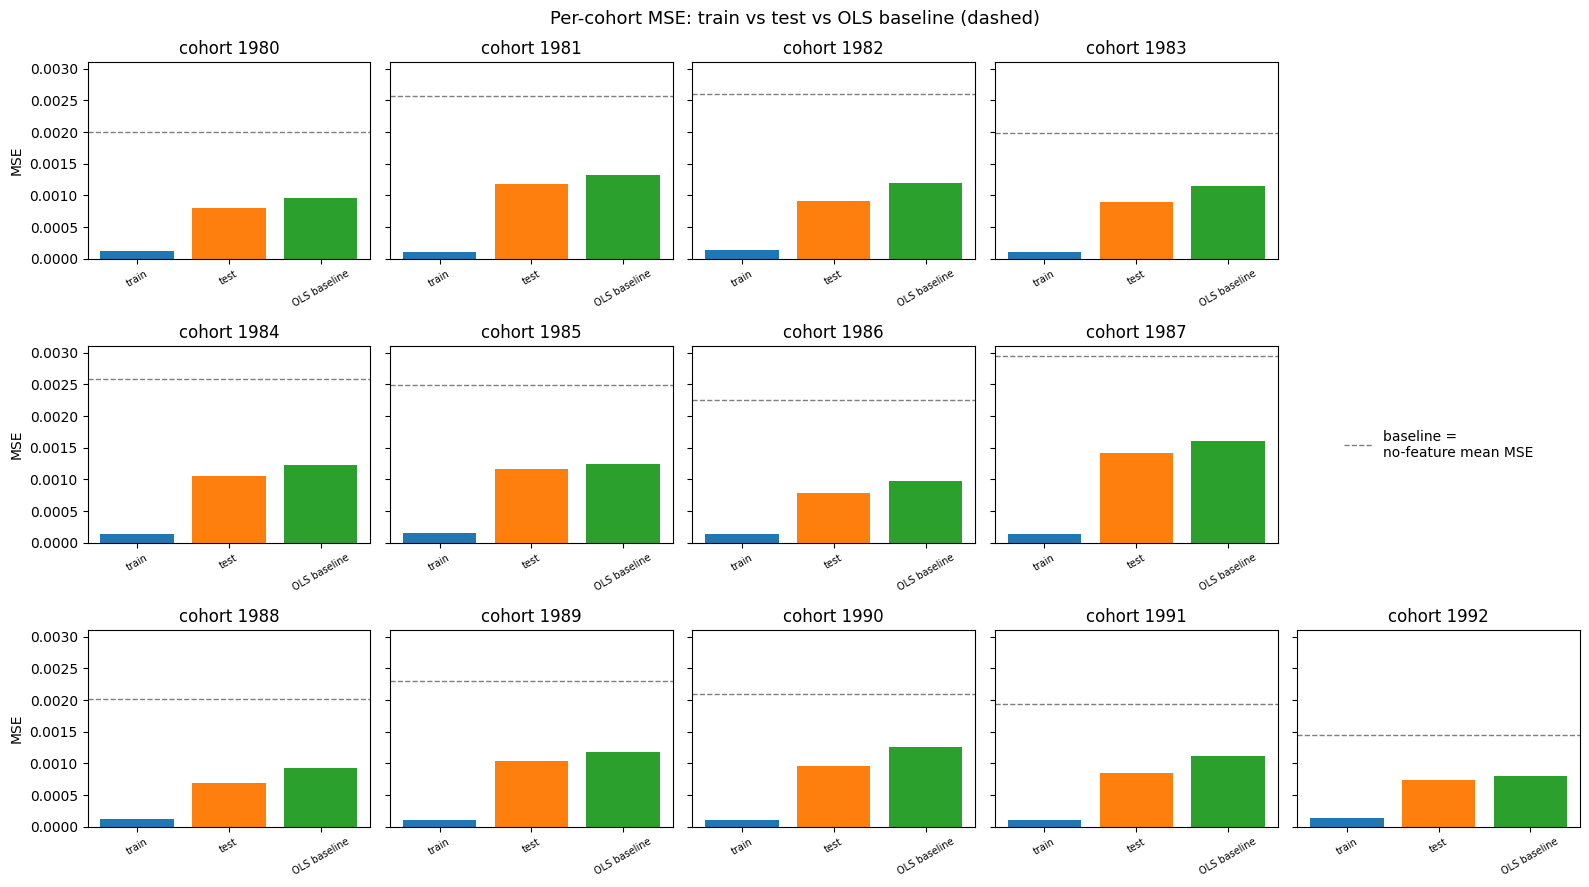

In [18]:
Cohorts = sorted(merged_cz["cohort"].unique()) # 1980-1992; 13 cohorts
best_params = rf_search.best_params_  # the tuned configuration we got

cohort_rows   = []   # one summary row per cohort, for the results table
cohort_models = {}   # keep each fitted forest + its test split for future reference

for coh in Cohorts:
    cohort_df = merged_cz[merged_cz["cohort"] == coh]
    Xc, yc = cohort_df[features], cohort_df[outcome]
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        Xc, yc, test_size=0.30, random_state=42)

    # One forest for each cohort and also an OLS estimate for each as benchmark.
    rf_coh = RandomForestRegressor(n_estimators=300, random_state=42, **best_params)
    rf_coh.fit(Xc_train, yc_train)
    ols_coh = LinearRegression().fit(Xc_train, yc_train)
    cohort_models[coh] = {"forest": rf_coh, "X_test": Xc_test, "y_test": yc_test}

    # Claude suggested a baseline of predicting the average mobility in
    # the training set for every test CZ; basically if it didn't consider
    # any of the features). The OLS should improve on this, and then RF
    # improves further (but prob not a lot).
    dumb_pred = np.full(len(yc_test), yc_train.mean())

    cohort_rows.append({
        "cohort":       coh,
        "n":            len(cohort_df),
        "rf_train_mse":    mean_squared_error(yc_train, rf_coh.predict(Xc_train)),
        "rf_test_mse":     mean_squared_error(yc_test,  rf_coh.predict(Xc_test)),
        "ols_test_mse": mean_squared_error(yc_test,  ols_coh.predict(Xc_test)),
        "test_r2":      r2_score(yc_test, rf_coh.predict(Xc_test)),
        "dumb_mse": mean_squared_error(yc_test, dumb_pred),
    })

cohort_table = pd.DataFrame(cohort_rows)
print(cohort_table.round(5))

# a smaller, modified version of the table to more clearly
# pit RF test MSE against OLS test MSE
gap_table = cohort_table[["cohort", "ols_test_mse", "rf_test_mse"]]
gap_table["difference"] = gap_table["ols_test_mse"]-gap_table["rf_test_mse"]
gap_table["pct_difference"] = (100*gap_table["difference"]/gap_table["ols_test_mse"]).round(1)

print(f"\n\nRF advantage over OLS is stable and modest.")
print(gap_table.round(5))

# visualizing the dataframe as 13 plots with common y-axis.
# This part is totally Claude-generated, as I didn't know how to format
# such that there are 2 rows with 4 cohort-plots each and the 3rd row with 5.
# I've still written my own annotations so I understand.

bar_labels = ["train", "test", "OLS baseline"]

fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharey=True)

# one slot for each cohort, a 3x5 grid that will have 2 slots empty.
slots = [(0, 0), (0, 1), (0, 2), (0, 3),
         (1, 0), (1, 1), (1, 2), (1, 3),
         (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]

for (r, c), row in zip(slots, cohort_table.to_dict("records")):
    ax = axes[r][c]
    ax.bar(bar_labels,
           [row["rf_train_mse"], row["rf_test_mse"], row["ols_test_mse"]],
           color=["tab:blue", "tab:orange", "tab:green"])
    ax.axhline(row["dumb_mse"], color="tab:gray", linestyle="--", linewidth=1)
    ax.set_title(f"cohort {int(row['cohort'])}")
    ax.tick_params(axis="x", labelsize=7, rotation=30)

# Switching off the two unused cells with no plot.
axes[0][4].axis("off")
axes[1][4].axis("off")
dumb_baseline_handle = Line2D([0], [0], color="tab:gray", linestyle="--", linewidth=1)
axes[1][4].legend([dumb_baseline_handle], ["baseline =\nno-feature mean MSE"],
                  loc="center", frameon=False)

# putting one y-label per row on the leftmost panel.
for r in range(3):
    axes[r][0].set_ylabel("MSE")

fig.suptitle("Per-cohort MSE: train vs test vs OLS baseline (dashed)", fontsize=13)
plt.tight_layout()
print("\n\n")
plt.show()

# For each cohort: OLS and RF outperform the dumb, no-feature baseline;
# RF outperforms OLS (but by a very slim margin);
# and the model generalizes the overfit trees from training.

# 5. Answering my RQ: what are the most important predictors of economic mobility?
Following the tutorial's example, scoring is done with negative MSE - an increase in test MSE when a feature's column is shuffled means it was more important to the model's predictions.

,feature,importance
rank,,
1,singlepar_pooled1980,0.00062
2,share_white1980,0.00031
3,foreign_share1980,0.00020
4,emp_pooled1980,0.00016
5,poor_share_pooled1980,0.00012
6,percap_inc_pooled1980,0.00002
7,frac_coll_pooled1980,0.00002
8,hhinc_median_pooled1980,0.00002
,feature,importance


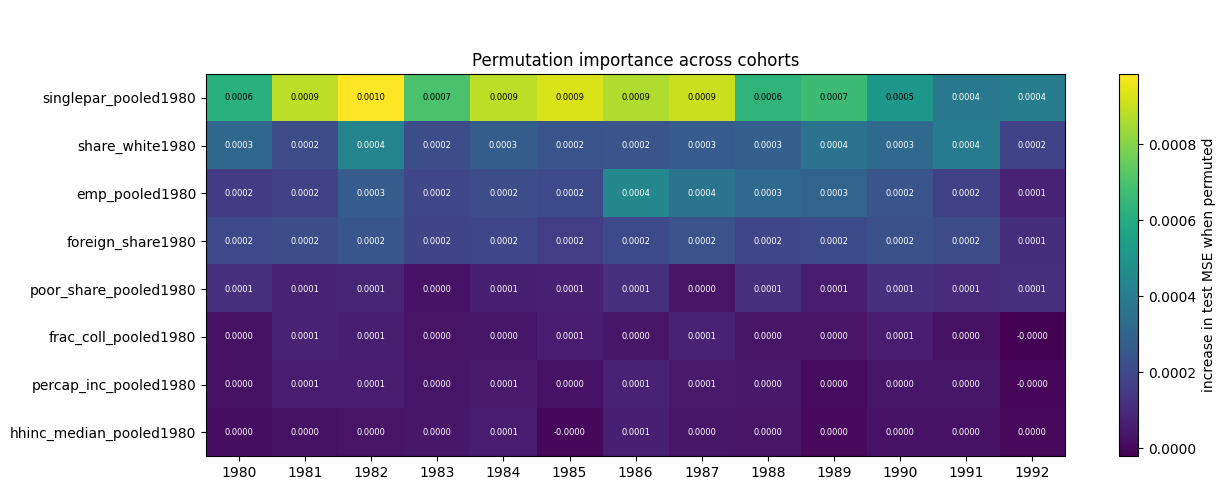

In [19]:
# Permutation importance per cohort
importance_by_cohort = {}
for coh in Cohorts:
    cohort_model = cohort_models[coh]
    perm_result = permutation_importance(
        cohort_model["forest"], cohort_model["X_test"], cohort_model["y_test"],
        scoring="neg_mean_squared_error", n_repeats=20, random_state=0, n_jobs=-1)
    importance_by_cohort[coh] = pd.Series(perm_result.importances_mean, index=features)

importance_table = pd.DataFrame(importance_by_cohort)

# One ranked table per cohort: rank by most important to least
cohort_importance = {}
for coh in Cohorts:
    sorted_importance = importance_table[coh].sort_values(ascending=False)
    ranked_table = pd.DataFrame(
        {"feature": sorted_importance.index,
         "importance": sorted_importance.values.round(5)},
        index=range(1, len(sorted_importance) + 1),
    )
    ranked_table.index.name = "rank"
    cohort_importance[coh] = ranked_table

# Showing the ranked tables, 5 per row. I asked Claude to give me an alternative
# to display() because that stacked the tables vertically; too much scrolling!
cells = ""
for coh in Cohorts:
    cells += (f'<div style="font-size:11px; padding:4px;">'
              f'<b>cohort {coh}</b>{cohort_importance[coh].to_html()}</div>')
display(HTML(f'<div style="display:grid; grid-template-columns:repeat(5, max-content);'
             f'gap:14px;">{cells}</div>'))

# visualization using heatmap; I also asked Claude to build this entirely,
# as I thought it'd be easier for comparison but the tutorial didn't provide a guide.
feature_order = importance_table.mean(axis=1).sort_values(ascending=False).index
heatmap_data = importance_table.loc[feature_order]

fig, ax = plt.subplots(figsize=(13, 5))
heatmap_image = ax.imshow(heatmap_data.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([int(cohort) for cohort in heatmap_data.columns])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Letting the text color flip so it stays readable on dark vs bright cells.
text_color_threshold = heatmap_data.values.max() / 2
for row_idx in range(heatmap_data.shape[0]):
    for col_idx in range(heatmap_data.shape[1]):
        value = heatmap_data.values[row_idx, col_idx]
        ax.text(col_idx, row_idx, f"{value:.4f}", ha="center", va="center",
                color="black" if value > text_color_threshold else "white", fontsize=6)

fig.colorbar(heatmap_image, ax=ax, label="increase in test MSE when permuted")
ax.set_title("\n\nPermutation importance across cohorts")
plt.tight_layout()
plt.show()



# 6. What this taught me about the method, limitations, and AI disclosure

### What I learned:
I think that my research question's specification showed me a less "flashy" lesson about random forests: they're not always better than a plain linear regression. For each of the cohorts born from 1980-92, RF did consistently have less test error than OLS when predicting their adult economic mobility, but only around 17% on average. The relationship at the CZ level turned out to be largely linear and additive, so there wasn't much nonlinearity or interaction for the forest's flexibility to capture.This is a nice conclusion, I think, both as a soft robustness check on Chetty's work and as a reminder to "trust but verify": I trust that machine learning offers more tools to analyze data and those tools can be more true to capturing flexible data patterns, but it must be verified that the data has that complexity in the first place, rather than assumed and automatically tossing simpler econometric tools out.

Another insight that this project helped solidify is that powerful techniques like RF are also constrained by the data it's used on. RF has an edge on bagging because it decorrelates trees; the tuning
led to only 2 of 8 features considered at each split, so the optimal decorrelation was pretty aggressive actually. Yet, I think correlation remained in my data itself and was seen in the permutation importance tables. Most of the predictors seem to overlap in measuring local poverty; ex. poverty share, per-capita income, and employment. Some of the features may have masked each other's permutation importance, but the fact that there were some shifts in permutation ranking across cohorts seems like a good sign to me.

### Limitations:
1. Data granularity: Since commuting zone covariates reported in Table 9 were measured only in the years 1980, 1990, 2009, and 2010, I didn't have precise enough data to get at an exact "circumstance at birth" effect for cohorts. For the 1980 cohort, the 1980 covariates were exact, but for the 1989, only a proxy and perhaps more of a "formative years" effect. I wish I had measures of the covariates at a more granular level within decades to better match birth cohorts with covariate levels that they received more directly in their first years of life.
2. Data reported as averages: The economic mobility data contains averages across groups rather than individual-level outcomes. Since averaging smooths out curvature, I suppose it could be that there are nonlinear interactions going on between covariates at the household level but that are flattened out at the CZ-level.
3. Collinearity concern, especially with only 8 features ultimately considered: as I mentioned, the covariates likely move together because they are reflections of the same underlying local characteristics of the commuting zone. The permutation importance tables should be taken with a grain of salt, because RF cannot "see through" how importance might be shared among covariates when making splits.

### AI disclosure:
I consulted with Claude AI to narrow my research question, to generate baseline code, and to clarify my understanding of my results. All annotations in the code are mine.
A side note on disclosing external help: I also solidified my research question and project outline in conversation with Daniel. I appreciate his availability after lecture to discuss with me and offer some guidance!